# L09 — k-Space Encoding (Hands-on notebook)

**Module 2, Day 12 of MRI Zero-to-Hero**

This notebook brings the abstract math of L09 to life with three runnable demonstrations:

1. **The 1D phase-wave intuition** — reproduce the lecture's worked examples (signal = sum of arrows).
2. **k-Space ↔ image-space mapping** — take a real MR image, transform to k-space, mask different regions, and see what comes back.
3. **Designing k-space trajectories** — build Cartesian and radial sampling patterns from gradient waveforms.
4. **The point spread function (PSF)** — see how a finite k-space sampling region blurs the image.

Run each cell in order. Modify parameters and re-run cells to build intuition.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Circle

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100
np.random.seed(0)

---
## 1. The 1D phase-wave intuition

Reproduce the lecture's three worked examples. We have 9 spins evenly spaced from $x = 0$ to $x = 8$ mm, all with unit magnitude. After a gradient has been applied, each spin has accumulated phase $\varphi_\text{G}(x) = 2\pi k x$.

The signal is the coherent sum of all arrows: $S = \sum_n e^{i \varphi_\text{G}(x_n)}$.

In [2]:
def spin_lineup(k_value_per_mm, n_spins=9, x_max_mm=8, magnitudes=None):
    """Draw a row of spins with phases determined by k. Returns the complex signal."""
    positions = np.linspace(0, x_max_mm, n_spins)
    phases = 2 * np.pi * k_value_per_mm * positions  # phi_G(x) = 2 pi k x
    if magnitudes is None:
        magnitudes = np.ones(n_spins)
    arrows = magnitudes * np.exp(1j * phases)
    signal = np.sum(arrows)

    fig, ax = plt.subplots(figsize=(11, 2))
    for i, (x, phi, mag) in enumerate(zip(positions, phases, magnitudes)):
        ax.add_patch(Circle((x, 0), 0.35, fill=False, edgecolor='black', lw=1))
        # arrow
        dx = 0.32 * mag * np.cos(phi)
        dy = 0.32 * mag * np.sin(phi)
        ax.add_patch(FancyArrowPatch((x, 0), (x + dx, dy),
                                      arrowstyle='-|>', mutation_scale=14,
                                      color='crimson', lw=1.5))
        ax.text(x, -0.7, f"{phi/np.pi:.2f}π", ha='center', fontsize=8)
    ax.set_xlim(-0.8, x_max_mm + 0.8)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"k = {k_value_per_mm:.4f} mm⁻¹    →    signal = {signal:.3f}    |signal| = {abs(signal):.3f}")
    plt.tight_layout()
    plt.show()
    return signal

### Case 1 — No gradient applied ($k = 0$)
All spins are inphase. The signal is the maximum possible: 9 (one for each unit-magnitude spin).

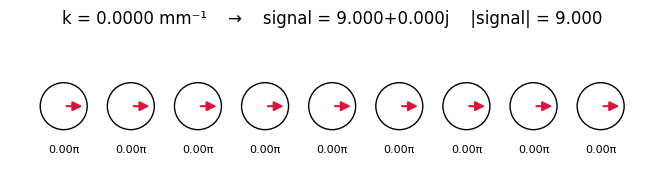

Signal = (9+0j)   →   maximum signal, all arrows aligned


In [3]:
s = spin_lineup(k_value_per_mm=0.0)
print(f"Signal = {s}   →   maximum signal, all arrows aligned")

### Case 2 — Half a wavelength fits in the sample ($k = 1/16$ mm⁻¹)
The phase varies from 0 at $x=0$ to $\pi$ at $x=8$ mm. Arrows partially cancel — the signal magnitude drops dramatically, and (crucially) the signal is now **imaginary**.

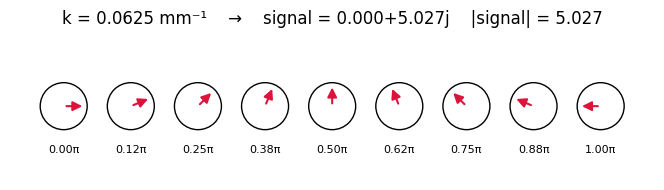

Signal = 0.000+5.027j   →   imaginary, |S| ≈ 5.03


In [4]:
s = spin_lineup(k_value_per_mm=1/16)
print(f"Signal = {s:.3f}   →   imaginary, |S| ≈ 5.03")

### Case 3 — One full wavelength fits in the sample ($k = 1/8$ mm⁻¹)
Now phase goes 0 → 2π across the sample. Arrows cancel almost completely — only the unpaired last spin survives.

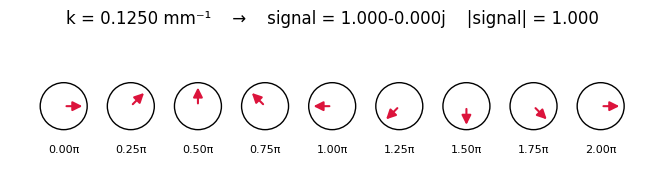

Signal ≈ 1.000-0.000j   →   almost full cancellation


In [5]:
s = spin_lineup(k_value_per_mm=1/8)
print(f"Signal ≈ {s:.3f}   →   almost full cancellation")

### Case 4 — Non-uniform magnetization (from the lecture)
If the magnetization magnitude varies across the sample, the signal becomes a non-trivial complex number. In the lecture this represents the realistic case — the underlying "image" has structure.

In [6]:
# Lecture example (slide 'Position-dependent magnitude of the magnetization'):
# 9 spins, k = 1/8 mm⁻¹ (so phase steps of π/4), with non-uniform magnitudes.
# Magnitudes (lecture): 0.4, 0.4, 0.8, 0.8, 0.6, 1.0, 0.6, 0.8, 0.8
# Note: the lecture's '−0.6' is just 0.6 · e^(iπ), which the formula handles
# automatically since at x = 4 mm with k = 1/8 mm⁻¹, the phase is already π.
magnitudes = np.array([0.4, 0.4, 0.8, 0.8, 0.6, 1.0, 0.6, 0.8, 0.8])
k = 1/8
x_max = 8
n = 9
x = np.linspace(0, x_max, n)
phi = 2*np.pi*k*x
arrows = magnitudes * np.exp(1j*phi)
signal = arrows.sum()
print(f"Signal = {signal:.4f}")
print(f"        = |S| · exp(i·arg) where |S| = {abs(signal):.4f}, arg = {np.angle(signal):.4f} rad")
print("        (lecture gives ≈ 0.285 · exp(-i · 0.9061) — matches.)")

Signal = 0.1757-0.2243j
        = |S| · exp(i·arg) where |S| = 0.2849, arg = -0.9061 rad
        (lecture gives ≈ 0.285 · exp(-i · 0.9061) — matches.)


**The big takeaway:** As we sweep $k$ from 0 outward, the signal magnitude generally decreases (more cancellation) but the *complex* signal value at each $k$ encodes information about the spatial distribution of magnetization. **That's the Fourier transform**, computed coherently by the spins themselves.

---
## 2. k-Space ↔ image-space mapping on a synthetic phantom

Now the 2D version. We'll make a Shepp-Logan-style phantom, take its 2D FFT (that's our "acquired k-space"), then mask different regions and inverse-transform to see what we lose.

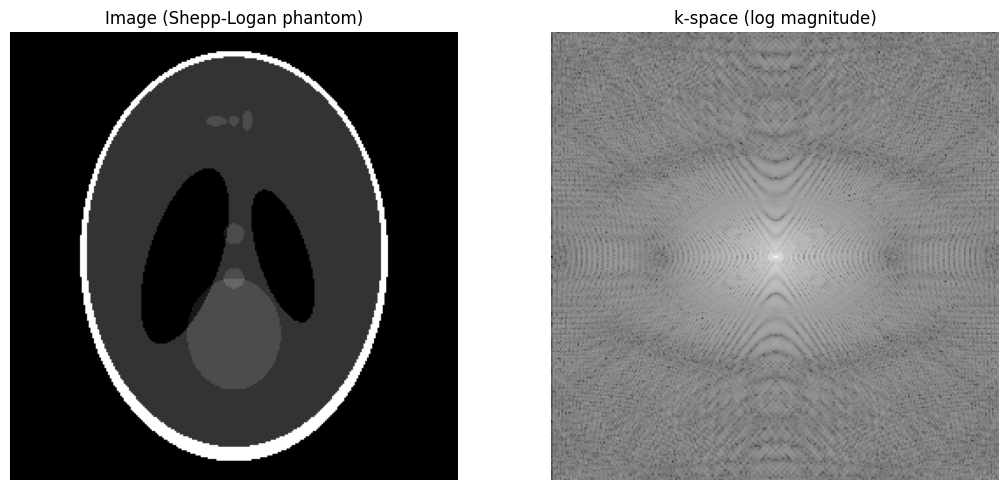

In [7]:
def shepp_logan(N=256):
    """A simple Shepp-Logan-like phantom (ellipses on a grid)."""
    ellipses = [
        # (intensity, a, b, x0, y0, phi_deg)  — Shepp-Logan canonical parameters
        ( 1.0,  0.69,  0.92,  0.0,    0.0,    0),
        (-0.8,  0.6624,0.874, 0.0,   -0.0184, 0),
        (-0.2,  0.11,  0.31,  0.22,   0.0,   -18),
        (-0.2,  0.16,  0.41, -0.22,   0.0,    18),
        ( 0.1,  0.21,  0.25,  0.0,    0.35,   0),
        ( 0.1,  0.046, 0.046, 0.0,    0.1,    0),
        ( 0.1,  0.046, 0.046, 0.0,   -0.1,    0),
        ( 0.1,  0.046, 0.023,-0.08,  -0.605,  0),
        ( 0.1,  0.023, 0.023, 0.0,   -0.606,  0),
        ( 0.1,  0.023, 0.046, 0.06,  -0.605,  0),
    ]
    x = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, x)
    img = np.zeros_like(X)
    for intensity, a, b, x0, y0, phi in ellipses:
        c, s = np.cos(np.deg2rad(phi)), np.sin(np.deg2rad(phi))
        xp = (X - x0)*c + (Y - y0)*s
        yp = -(X - x0)*s + (Y - y0)*c
        mask = (xp/a)**2 + (yp/b)**2 <= 1
        img[mask] += intensity
    return img

img = shepp_logan(N=256)
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].imshow(img, cmap='gray'); ax[0].set_title("Image (Shepp-Logan phantom)"); ax[0].axis('off')

# 2D FFT to get k-space
kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img)))

# k-space is complex, show log-magnitude
ax[1].imshow(np.log(np.abs(kspace) + 1e-2), cmap='gray')
ax[1].set_title("k-space (log magnitude)"); ax[1].axis('off')
plt.tight_layout(); plt.show()

### Roundtrip check
If we inverse-FFT the full k-space, we should get the original image back exactly (up to numerical precision). This confirms the equation $S(\mathbf{r}) = \mathcal{F}^{-1}\{\tilde{S}(\mathbf{k})\}$.

In [8]:
img_recon = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace))))
print(f"Max abs error after roundtrip: {np.max(np.abs(img - img_recon)):.2e}")
print("(Should be near machine precision — the FFT is its own inverse.)")

Max abs error after roundtrip: 4.44e-16
(Should be near machine precision — the FFT is its own inverse.)


### Experiment 2a — Keep only the k-space center
**Hypothesis (from the lecture): center of k-space → contrast and brightness, no fine detail.** We expect a blurred-but-correctly-bright image.

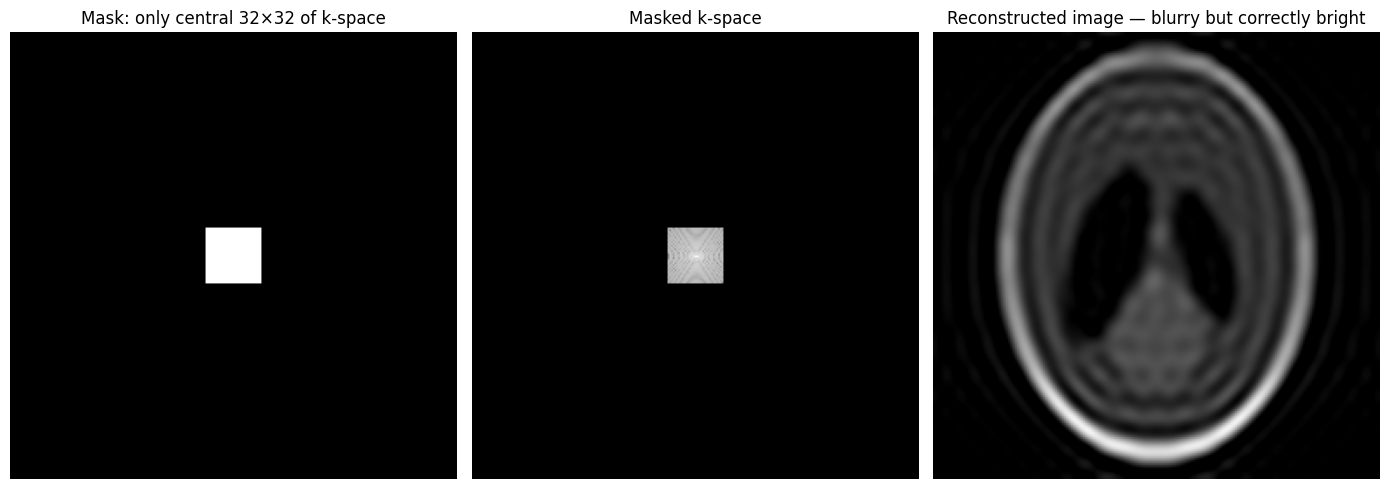

In [9]:
def apply_kspace_mask(kspace, mask):
    masked = kspace * mask
    img_back = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(masked))))
    return masked, img_back

N = kspace.shape[0]
center = N // 2

# Box mask centered on origin, half-size 16 px (out of 256)
mask_center = np.zeros_like(kspace, dtype=float)
half = 16
mask_center[center-half:center+half, center-half:center+half] = 1

masked, img_back = apply_kspace_mask(kspace, mask_center)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(mask_center, cmap='gray'); ax[0].set_title("Mask: only central 32×32 of k-space"); ax[0].axis('off')
ax[1].imshow(np.log(np.abs(masked)+1e-2), cmap='gray'); ax[1].set_title("Masked k-space"); ax[1].axis('off')
ax[2].imshow(img_back, cmap='gray', vmin=img.min(), vmax=img.max())
ax[2].set_title("Reconstructed image — blurry but correctly bright"); ax[2].axis('off')
plt.tight_layout(); plt.show()

### Experiment 2b — Keep only the k-space periphery (punch out the center)
**Hypothesis: periphery of k-space → edges and resolution, no brightness.** We expect an edge-detection-like image with no DC content.

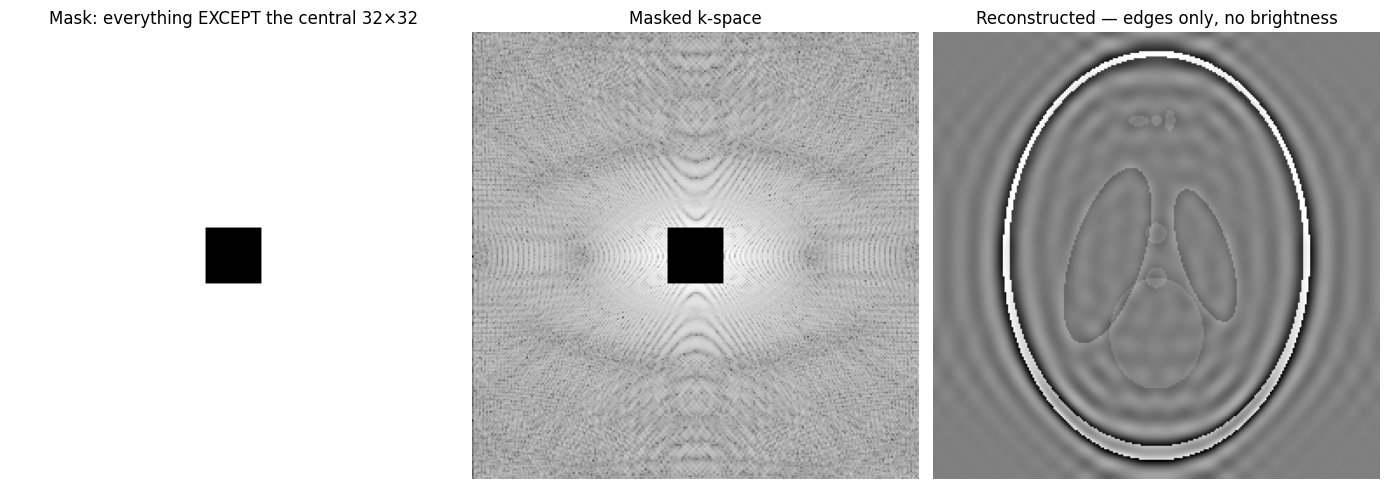

In [10]:
mask_periphery = np.ones_like(kspace, dtype=float)
mask_periphery[center-half:center+half, center-half:center+half] = 0

masked, img_back = apply_kspace_mask(kspace, mask_periphery)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(mask_periphery, cmap='gray'); ax[0].set_title("Mask: everything EXCEPT the central 32×32"); ax[0].axis('off')
ax[1].imshow(np.log(np.abs(masked)+1e-2), cmap='gray'); ax[1].set_title("Masked k-space"); ax[1].axis('off')
# Use symmetric color limits since this is an edge image (positive and negative)
vmax = np.percentile(np.abs(img_back), 99)
ax[2].imshow(img_back, cmap='gray', vmin=-vmax, vmax=vmax)
ax[2].set_title("Reconstructed — edges only, no brightness"); ax[2].axis('off')
plt.tight_layout(); plt.show()

**This is the lecture's mantra confirmed visually:** k-space center = contrast, k-space edge = resolution.

### Experiment 2c — Anisotropic resolution
What if we sample only a horizontal band of k-space? The lecture predicts: resolution will be lost in the direction perpendicular to the band.

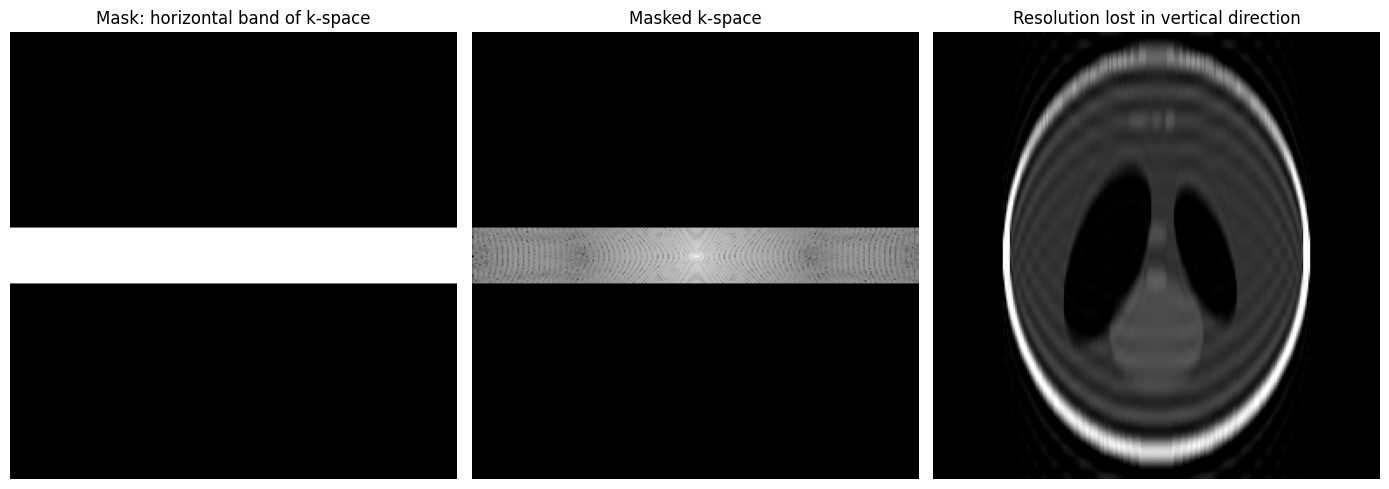

In [11]:
mask_band = np.zeros_like(kspace, dtype=float)
mask_band[center-16:center+16, :] = 1  # narrow horizontal band

masked, img_back = apply_kspace_mask(kspace, mask_band)

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(mask_band, cmap='gray'); ax[0].set_title("Mask: horizontal band of k-space"); ax[0].axis('off')
ax[1].imshow(np.log(np.abs(masked)+1e-2), cmap='gray'); ax[1].set_title("Masked k-space"); ax[1].axis('off')
ax[2].imshow(img_back, cmap='gray', vmin=img.min(), vmax=img.max())
ax[2].set_title("Resolution lost in vertical direction"); ax[2].axis('off')
plt.tight_layout(); plt.show()

Notice the vertical streaking. We sampled $k_x$ across the full range but only a narrow range of $k_y$ — so vertical resolution is poor, horizontal resolution is fine. The image is **anisotropic**.

---
## 3. k-Space trajectories from gradient waveforms

Let's build the trajectories we discussed. Recall: $\mathbf{k}(t) = (\gamma / 2\pi) \int_0^t \mathbf{G}(t')\, dt'$. We'll set $\gamma / 2\pi = 1$ (in normalized units) for clarity.

In [12]:
def trajectory_from_gradient(Gx, Gy, dt=1.0):
    """Integrate gradient waveforms to get k-space trajectory (gamma/2pi = 1)."""
    kx = np.cumsum(Gx) * dt
    ky = np.cumsum(Gy) * dt
    return kx, ky

def plot_trajectory(Gx, Gy, title="", ax_traj=None):
    """Plot gradient waveform alongside resulting k-space trajectory."""
    kx, ky = trajectory_from_gradient(Gx, Gy)
    t = np.arange(len(Gx))
    
    fig = plt.figure(figsize=(12, 4))
    ax1 = fig.add_subplot(1, 3, 1)
    ax1.plot(t, Gx, 'b', lw=2, label='$G_x$')
    ax1.plot(t, Gy, 'r', lw=2, label='$G_y$')
    ax1.axhline(0, color='k', lw=0.5)
    ax1.set_xlabel('time (samples)'); ax1.set_ylabel('gradient amplitude')
    ax1.set_title('Gradient waveforms'); ax1.legend(); ax1.grid(alpha=0.3)
    
    ax2 = fig.add_subplot(1, 3, 2)
    ax2.plot(kx, ky, 'k', lw=1.5)
    ax2.plot(kx[0], ky[0], 'go', markersize=10, label='start')
    ax2.plot(kx[-1], ky[-1], 'rs', markersize=10, label='end')
    ax2.set_xlabel('$k_x$'); ax2.set_ylabel('$k_y$')
    ax2.set_title('k-space trajectory'); ax2.legend()
    ax2.axhline(0, color='gray', lw=0.5); ax2.axvline(0, color='gray', lw=0.5)
    ax2.set_aspect('equal'); ax2.grid(alpha=0.3)
    
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.plot(t, kx, 'b', lw=2, label='$k_x$')
    ax3.plot(t, ky, 'r', lw=2, label='$k_y$')
    ax3.set_xlabel('time (samples)'); ax3.set_ylabel('k-value')
    ax3.set_title('k(t)'); ax3.legend(); ax3.grid(alpha=0.3)
    
    if title:
        fig.suptitle(title, y=1.02, fontsize=12, weight='bold')
    plt.tight_layout(); plt.show()
    return kx, ky

### 3a — Pure $G_x$ pulse: walk right in k-space

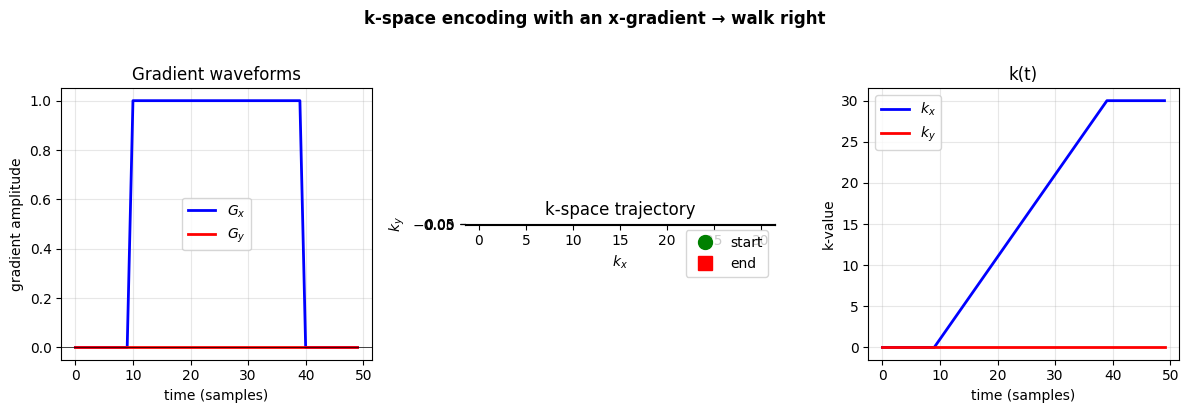

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,
         4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
        17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29.,
        30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [13]:
N = 50
Gx = np.concatenate([np.zeros(10), np.ones(30), np.zeros(10)])
Gy = np.zeros(N)
plot_trajectory(Gx, Gy, title="k-space encoding with an x-gradient → walk right")

### 3b — Negative $G_x$ pulse: walk left in k-space

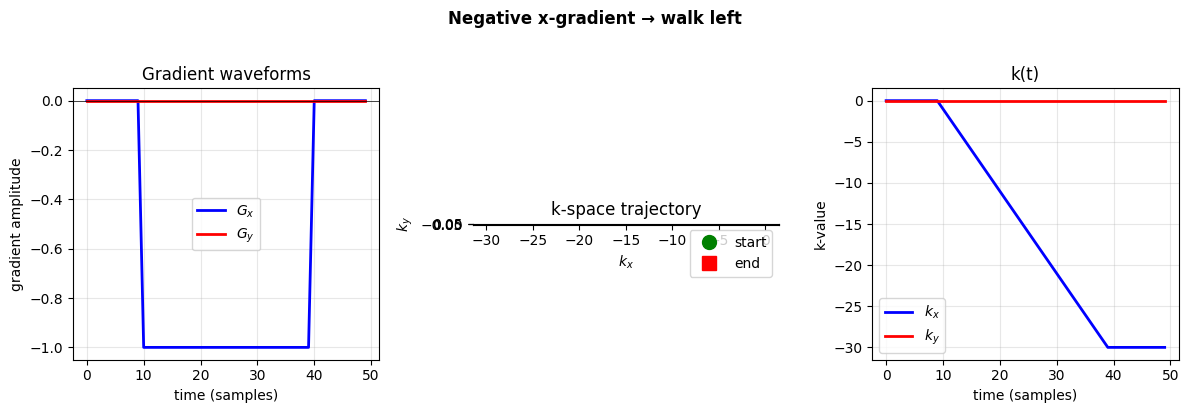

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  -1.,
         -2.,  -3.,  -4.,  -5.,  -6.,  -7.,  -8.,  -9., -10., -11., -12.,
        -13., -14., -15., -16., -17., -18., -19., -20., -21., -22., -23.,
        -24., -25., -26., -27., -28., -29., -30., -30., -30., -30., -30.,
        -30., -30., -30., -30., -30., -30.]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]))

In [14]:
Gx = np.concatenate([np.zeros(10), -np.ones(30), np.zeros(10)])
Gy = np.zeros(N)
plot_trajectory(Gx, Gy, title="Negative x-gradient → walk left")

### 3c — Simultaneous $G_x$ and $G_y$: walk diagonally

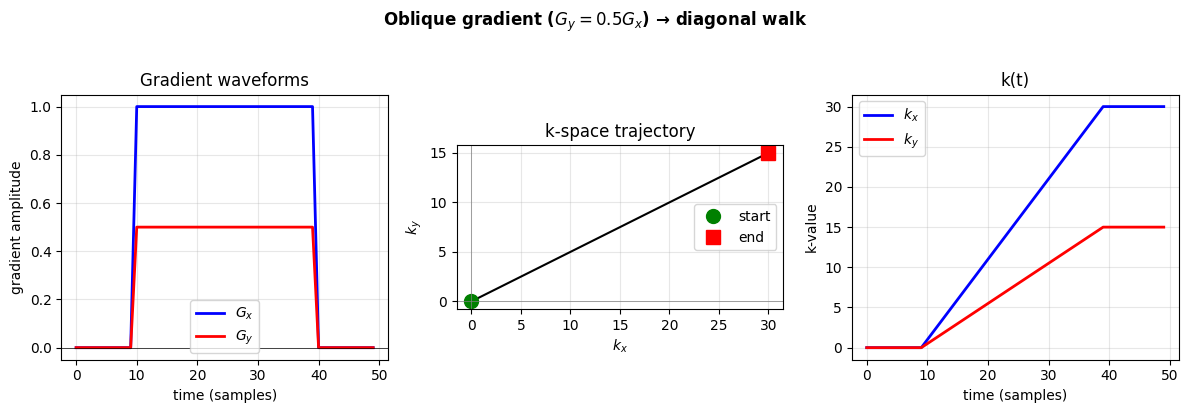

(array([ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  2.,  3.,
         4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13., 14., 15., 16.,
        17., 18., 19., 20., 21., 22., 23., 24., 25., 26., 27., 28., 29.,
        30., 30., 30., 30., 30., 30., 30., 30., 30., 30., 30.]),
 array([ 0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.5,
         1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
         6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5,
        12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15. , 15. , 15. , 15. ,
        15. , 15. , 15. , 15. , 15. , 15. ]))

In [15]:
Gx = np.concatenate([np.zeros(10), np.ones(30), np.zeros(10)])
Gy = np.concatenate([np.zeros(10), 0.5*np.ones(30), np.zeros(10)])
plot_trajectory(Gx, Gy, title="Oblique gradient ($G_y = 0.5 G_x$) → diagonal walk")

### 3d — A complete Cartesian readout: prephase + readout

This is what one phase-encoding line in a 2D Cartesian acquisition looks like:
1. **Prephase**: simultaneous negative $G_x$ and positive $G_y$ — takes us from origin to $(-k_{\max}, k_y^{(n)})$.
2. **Readout**: positive $G_x$ while sampling — walks us across one $k_y$ line.

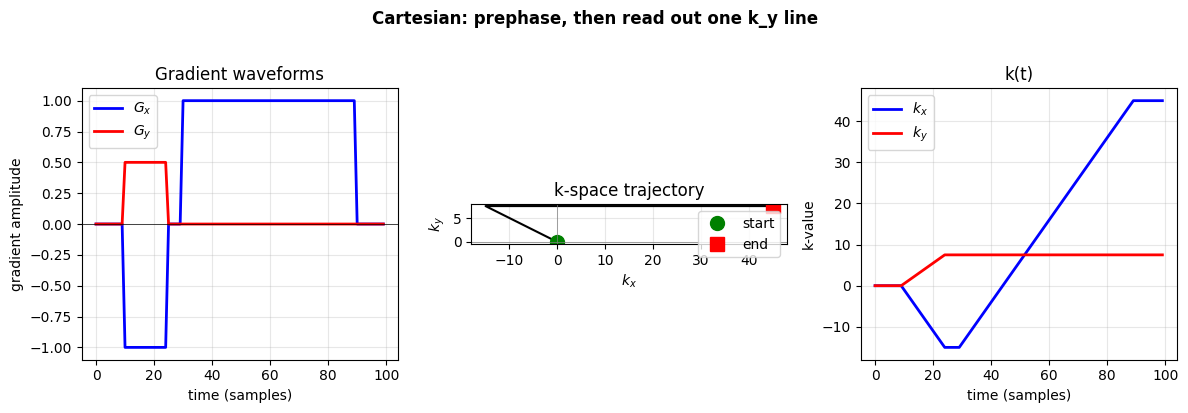

During readout (samples 30–90), we walk across k_x at fixed k_y. This is the line we acquire.


In [16]:
# Prephase: pull back to (-k_max, k_y_line) — uses both gradients
# Readout: positive G_x to scan across
N = 100
Gx = np.zeros(N); Gy = np.zeros(N)
# Prephase (time 10-25)
Gx[10:25] = -1
Gy[10:25] =  0.5
# Readout (time 30-90)
Gx[30:90] = +1
kx, ky = plot_trajectory(Gx, Gy, title="Cartesian: prephase, then read out one k_y line")
print("During readout (samples 30–90), we walk across k_x at fixed k_y. This is the line we acquire.")

### 3e — Full Cartesian coverage: many lines

To cover all of k-space, you repeat the above for many different prephase $G_y$ amplitudes. Each repetition is a separate TR with a separate RF excitation.

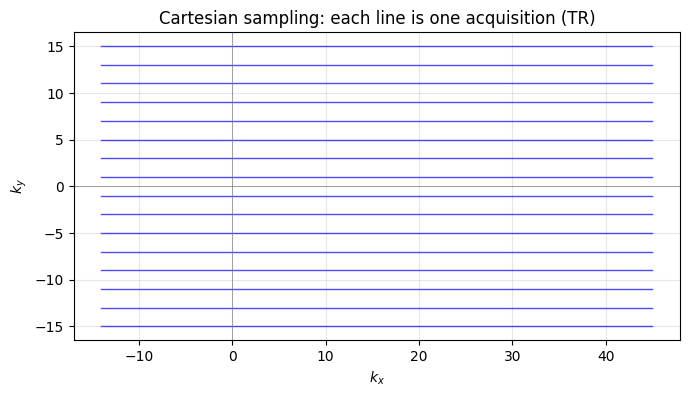

In [17]:
n_lines = 16
fig, ax = plt.subplots(figsize=(7, 7))
for i, gy_amp in enumerate(np.linspace(-1, 1, n_lines)):
    Gx = np.zeros(N); Gy = np.zeros(N)
    Gx[10:25] = -1; Gy[10:25] = gy_amp
    Gx[30:90] = +1
    kx, ky = trajectory_from_gradient(Gx, Gy)
    ax.plot(kx[30:90], ky[30:90], 'b', alpha=0.7, lw=1)  # only the readout portion
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_title('Cartesian sampling: each line is one acquisition (TR)')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

### 3f — Radial sampling: rotating gradient directions

For radial, each TR acquires one spoke through the origin. The angle of the spoke is set by the ratio of $G_x$ and $G_y$ during readout. Real radial sequences prephase to $-k_{\max}$ along the spoke direction, then read out across the origin to $+k_{\max}$.

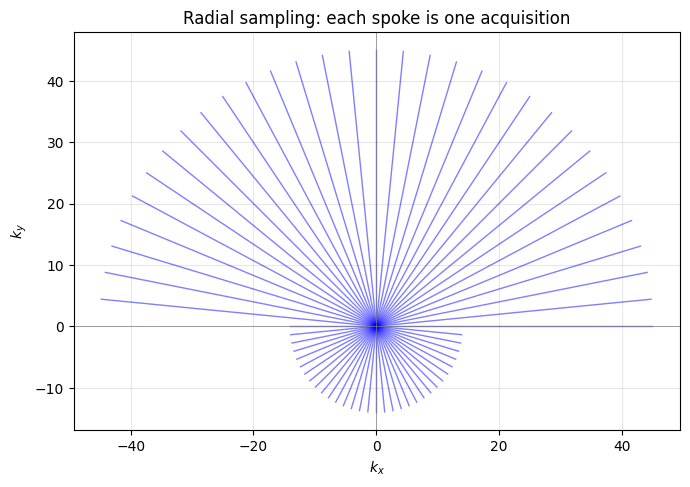

Note: radial oversamples the center (where all spokes converge) and undersamples the periphery.


In [18]:
n_spokes = 32
fig, ax = plt.subplots(figsize=(7, 7))
for i, theta in enumerate(np.linspace(0, np.pi, n_spokes, endpoint=False)):
    cx, cy = np.cos(theta), np.sin(theta)
    Gx = np.zeros(N); Gy = np.zeros(N)
    # Prephase along negative spoke direction
    Gx[10:25] = -cx; Gy[10:25] = -cy
    # Read out along positive spoke direction
    Gx[30:90] = cx;  Gy[30:90] = cy
    kx, ky = trajectory_from_gradient(Gx, Gy)
    ax.plot(kx[30:90], ky[30:90], 'b', alpha=0.5, lw=1)
ax.set_xlabel('$k_x$'); ax.set_ylabel('$k_y$')
ax.set_title('Radial sampling: each spoke is one acquisition')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("Note: radial oversamples the center (where all spokes converge) and undersamples the periphery.")

---
## 4. The point spread function (PSF)

Now the formal link between sampling pattern and image artifacts. 

**Setup:** If you sample k-space with sampling function $\tilde{T}(\mathbf{k})$ (1 where you sampled, 0 elsewhere), then:

$$S_\text{MRI}(\mathbf{r}) = S(\mathbf{r}) \ast T(\mathbf{r}), \quad T = \mathcal{F}^{-1}\{\tilde{T}\}$$

$T(\mathbf{r})$ is the **PSF** — the image of a single point through the imaging system.

Let's compute the PSF for full Cartesian sampling (box in k-space) and see why this is the canonical source of "sinc ringing" in MRI.

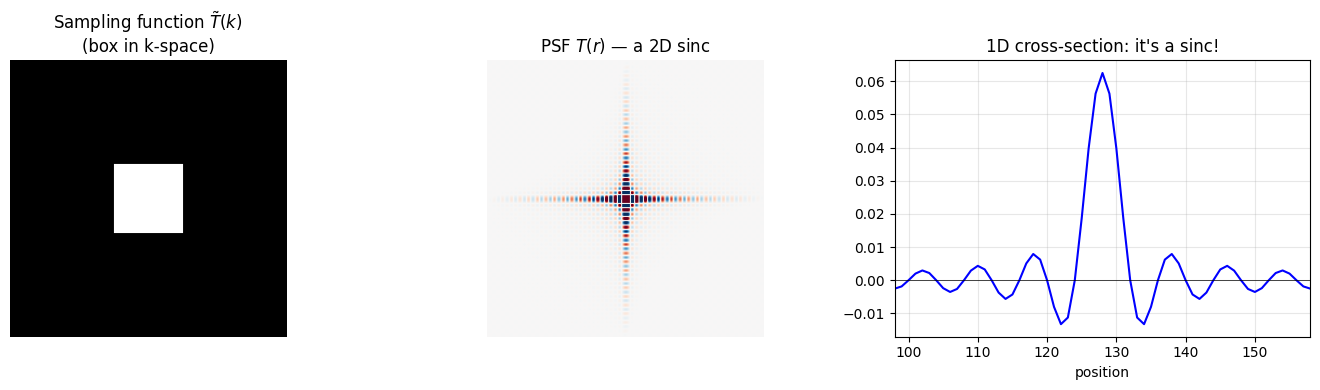

In [19]:
# A fully-sampled finite-region Cartesian mask
N = 256
T_kspace = np.zeros((N, N))
half = 32
T_kspace[N//2-half:N//2+half, N//2-half:N//2+half] = 1

T_image = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(T_kspace))))

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].imshow(T_kspace, cmap='gray'); ax[0].set_title("Sampling function $\\tilde{T}(k)$\n(box in k-space)"); ax[0].axis('off')
vmax_psf = np.percentile(np.abs(T_image), 99.5)
ax[1].imshow(T_image, cmap='RdBu_r', vmin=-vmax_psf, vmax=vmax_psf)
ax[1].set_title("PSF $T(r)$ — a 2D sinc"); ax[1].axis('off')
# Central 1D cross-section to see the sinc clearly
ax[2].plot(T_image[N//2, :], 'b', lw=1.5)
ax[2].axhline(0, color='k', lw=0.5)
ax[2].set_xlim(N//2 - 30, N//2 + 30)
ax[2].set_title("1D cross-section: it's a sinc!")
ax[2].set_xlabel('position'); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

Mathematically: $\mathcal{F}^{-1}\{\text{box}\} = \text{sinc}$. So sampling a finite region of k-space convolves the true image with a sinc → **ringing artifacts** near sharp edges. This is **Gibbs ringing**, which we'll see in much more detail in L11.

### Convolution demonstration: phantom blurred by the PSF

Now apply this PSF to our phantom and see what it does.

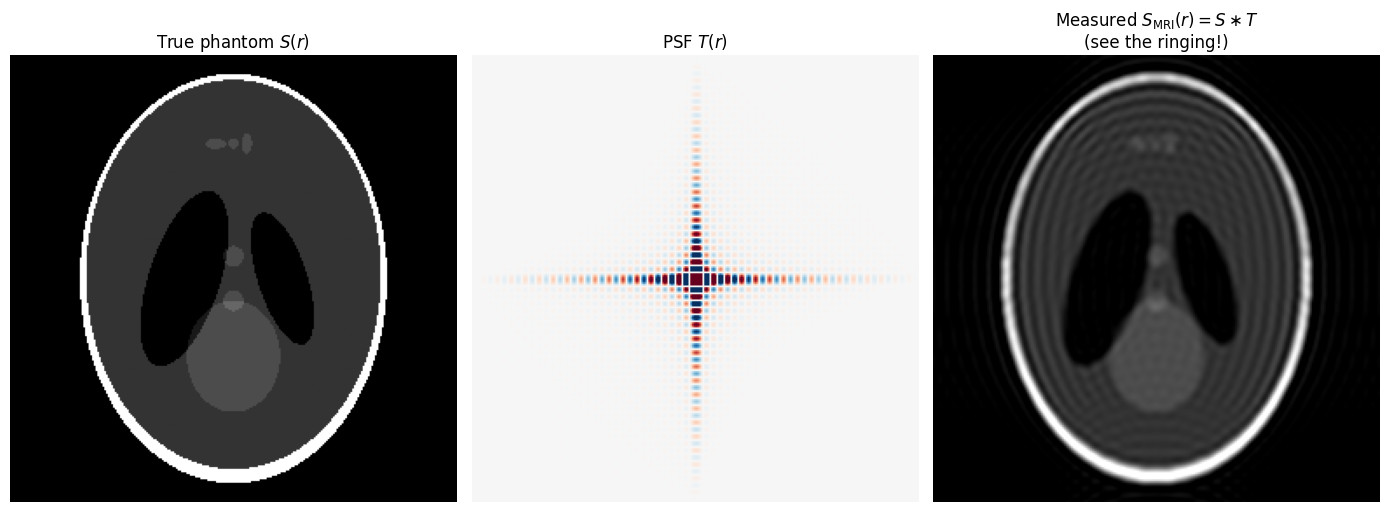

In [20]:
phantom = shepp_logan(N=256)
# Blurred phantom = phantom * T_kspace in k-space
K = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(phantom)))
K_masked = K * T_kspace
phantom_blurred = np.real(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(K_masked))))

fig, ax = plt.subplots(1, 3, figsize=(14, 5))
ax[0].imshow(phantom, cmap='gray'); ax[0].set_title("True phantom $S(r)$"); ax[0].axis('off')
ax[1].imshow(T_image, cmap='RdBu_r', vmin=-vmax_psf, vmax=vmax_psf)
ax[1].set_title("PSF $T(r)$"); ax[1].axis('off')
ax[2].imshow(phantom_blurred, cmap='gray', vmin=phantom.min(), vmax=phantom.max())
ax[2].set_title("Measured $S_\\text{MRI}(r) = S \\ast T$\n(see the ringing!)"); ax[2].axis('off')
plt.tight_layout(); plt.show()

The ringing patterns around sharp boundaries are the sinc's sidelobes leaking into the image. This is **the** fundamental MRI artifact and is why MR images don't have perfectly sharp edges even at perfect signal-to-noise.

---
## Try it yourself

Modify the cells above to explore further. A few suggestions:

1. **In Part 1**: Use 17 spins instead of 9, with $k = 1/16$ mm⁻¹. Does the signal still come out imaginary?

2. **In Part 2**: Change `half` in the center/periphery experiments. At what mask size does the image become diagnostically usable?

3. **In Part 3**: Design a gradient waveform that traces out a square in k-space (not just a line). What does it look like?

4. **In Part 4**: Use a *circular* k-space mask instead of a square. How does the PSF change? Why?

5. **Optional — try on real data**: download an image from `nibabel`'s test data (or a slice from any NIfTI file you have), repeat Part 2 on real data and see how the contrast vs. resolution decomposition looks.

---

## What you should now feel confident about

- **The MR signal is the Fourier transform of the image.** Not by some loose analogy — literally, by direct derivation from the Bloch dynamics + Faraday induction.
- **Gradients define a path through k-space.** $\mathbf{v}_k = (\gamma/2\pi)\mathbf{G}$.
- **k-space center ↔ contrast and brightness; k-space edge ↔ resolution.**
- **Cartesian vs. radial sampling** are just two of many ways to navigate k-space.
- **The PSF** is the inverse Fourier transform of the sampling function, and it tells you exactly how artifacts will appear in the image.